# 75 - Resolution roundtrip: original -> downsampled -> prediction -> upsampled

**Why this notebook exists.** We are moving to a model that predicts *many* boxes, each with a
different full-resolution `HxW`, by always predicting one standardized grid `(out_h, out_w)` and
mapping that back to each box's own resolution. That map back is the thing to look at before any
of it gets built, because it is easy to make it *look* right while it silently stretches or
offsets the prediction.

Every panel below is stamped with its own `HxW`. Nothing here retrains anything: the prediction
comes off an `OutputSaver` dump already on disk.

**The three questions this figure answers**

1. Does the anisotropic un-squash land the blob in the right place? (panel 1 vs panel 4)
2. Is the upsample *honest* - piecewise constant, inventing no detail the 100 lasers never
   measured? (panel 4 should be visibly blocky)
3. How badly does a square `32x32` grid distort a box whose aspect is not 1? (the
   square-cell vs true-aspect rows)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, glob, json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from model.dataset import downsample_mask, upsample_mask   # the SHIPPING pair, not a copy

EXP  = ROOT / "experiments/31_07_2026_gastronorm_exp1"
RUN  = ROOT / "runs/pm-p3-boombox-full-v1"
SPLIT = "1-cube-speaker"          # trained 1000 epochs; one cube reads clearly at 21x30

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "font.size": 9})
print(ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/ethantu/workspace/good-vibrations


## 1. Load one real forward pass

`OutputSaver` writes `{'mask_pred': (B,out_h,out_w) float16, 'info': {...}}` per eval batch
(`src/model/callbacks.py:104`). Two things to be careful about:

- `mask_pred` is **already sigmoid probabilities** (`src/model/boombox.py:287`). Do not re-sigmoid.
- `info['sample_id']` is an **int tensor**, but sample directories are zero-padded 6-digit
  names. The join is `f"{int(sid):06d}"`. This is the id-vs-row skew that
  `viz/tests/test_coordinates.py` exists to catch - get it wrong and every panel below shows a
  confidently mismatched pair, which looks like a broken model rather than a broken join.

In [2]:
dumps = sorted(glob.glob(str(RUN / "outputs_history/eval" / SPLIT / "*.pt")))
assert dumps, f"no dumps under {RUN}/outputs_history/eval/{SPLIT}"
dump = torch.load(dumps[-1], map_location="cpu", weights_only=False)

preds = dump["mask_pred"].float().numpy()                  # (B, out_h, out_w), already sigmoid
sids  = [f"{int(s):06d}" for s in dump["info"]["sample_id"]]   # int tensor -> padded dir name
boxes = list(dump["info"]["box"])

GRID_H, GRID_W = preds.shape[1:]
print(f"{Path(dumps[-1]).name}: {preds.shape} preds, grid {GRID_H}x{GRID_W}, "
      f"boxes={sorted(set(boxes))}, range [{preds.min():.3f}, {preds.max():.3f}]")

ep1000-ba000000.pt: (63, 21, 30) preds, grid 21x30, boxes=['gastronorm'], range [0.000, 1.000]


In [3]:
def sample_dir(sid): return EXP / "samples" / sid

def load_sample(sid):
    '''Everything for one sample at FULL resolution, straight off disk.'''
    d = sample_dir(sid)
    photo = Image.open(d / "image/02_cropped_overhead.png").convert("RGB")
    smask = Image.open(d / "image/03_smask.png")           # PIL, so downsample_mask can take it
    return photo, smask

def gt_grid(sid, h, w):
    '''Ground-truth grid. Uses the precomputed .npy when the dataset ships that size,
    otherwise calls downsample_mask directly - which is the same function that wrote them.'''
    npy = sample_dir(sid) / f"image/04_downsampled_smask_{h}h_{w}w.npy"
    if npy.exists(): return np.load(npy)
    return downsample_mask(Image.open(sample_dir(sid) / "image/03_smask.png"), h, w)

# sanity: does the geometry match what we think it is?
photo0, smask0 = load_sample(sids[0])
BOX_W, BOX_H = photo0.size
print(f"box '{boxes[0]}' full resolution: {BOX_W}x{BOX_H}  (aspect w/h = {BOX_W/BOX_H:.3f})")
assert smask0.size == photo0.size, "smask and photo must share the full-res frame"

box 'gastronorm' full resolution: 1337x1110  (aspect w/h = 1.205)


### Verify the id join before trusting anything else

If the `sample_id -> directory` join is wrong, every figure below is a plausible-looking lie -
it renders one sample's prediction against another sample's ground truth, which reads as a bad
model rather than a bad join.

Check it against fields that genuinely discriminate: `speaker` (1-8), `position_id`,
`n_objects` and `is_empty_box` all came from the sample's own `metadata.jsonl`, so agreeing on
all four for every row is strong evidence the join is right.

Note what is NOT usable here: `info['x_com']` / `info['y_com']` are `-1.0` for every sample on
this dataset. `dataset.py:190` defaults `downsampled_com` to `[-1,-1]` when the key is missing,
and these captures never wrote it. They are sentinels, not centres of mass - see the cell after
the check.

In [4]:
def meta(sid):
    # metadata.jsonl holds ONE KEY PER LINE, so lines must be merged.
    m = {}
    for line in (sample_dir(sid) / "metadata.jsonl").read_text().splitlines():
        if line.strip(): m.update(json.loads(line))
    return m

def com(g):
    # (row, col) centre of mass in grid units; matches utils.metrics.center_of_mass.
    tot = g.sum()
    if tot <= 0: return (np.nan, np.nan)
    rr, cc = np.mgrid[0:g.shape[0], 0:g.shape[1]]
    return (float((rr * g).sum() / tot), float((cc * g).sum() / tot))

FIELDS = ("speaker", "position_id", "n_objects", "is_empty_box")
bad = []
for i, sid in enumerate(sids):
    m = meta(sid)
    got = tuple(int(dump["info"][f][i]) for f in FIELDS)
    exp = tuple(int(bool(m[f])) if f == "is_empty_box" else int(m[f]) for f in FIELDS)
    if got != exp: bad.append((sid, got, exp))

print(f"{len(sids) - len(bad)}/{len(sids)} rows agree on {FIELDS}")
if bad:
    print("MISMATCH - the sample_id join is wrong. Stop; every figure below is meaningless.")
    for row in bad[:5]: print("  ", row)
else:
    print("join is sound: dump row i really is the sample directory sids[i]")

63/63 rows agree on ('speaker', 'position_id', 'n_objects', 'is_empty_box')
join is sound: dump row i really is the sample directory sids[i]


In [5]:
# The x_com/y_com sentinel, made explicit rather than left to surprise someone later.
xc, yc = np.asarray(dump["info"]["x_com"]), np.asarray(dump["info"]["y_com"])
if np.all(xc == -1) and np.all(yc == -1):
    print(f"NOTE: info['x_com'] / ['y_com'] are -1.0 for all {len(xc)} rows.")
    print("  'downsampled_com' is absent from these captures' metadata.jsonl, so dataset.py:190")
    print("  falls back to its [-1,-1] sentinel. Consequence: callbacks.py:_render_batch prints")
    print("  'com=(-1.0,-1.0)' in EVERY wandb caption on this dataset. viz is unaffected - it")
    print("  recomputes com from the mask itself (viz/data.py:176).")
    print("  Real com, recomputed from the ground-truth grid:")
    for sid in sids[:3]:
        r, c = com(gt_grid(sid, GRID_H, GRID_W))
        print(f"    {sid}: (row {r:.2f}, col {c:.2f}) of {GRID_H}x{GRID_W}")

NOTE: info['x_com'] / ['y_com'] are -1.0 for all 63 rows.
  'downsampled_com' is absent from these captures' metadata.jsonl, so dataset.py:190
  falls back to its [-1,-1] sentinel. Consequence: callbacks.py:_render_batch prints
  'com=(-1.0,-1.0)' in EVERY wandb caption on this dataset. viz is unaffected - it
  recomputes com from the mask itself (viz/data.py:176).
  Real com, recomputed from the ground-truth grid:
    000047: (row 3.77, col 5.54) of 21x30
    000055: (row 3.67, col 7.66) of 21x30
    000064: (row 3.56, col 9.84) of 21x30


## 2. The four panels

| panel | what | size |
|---|---|---|
| 1 | original photo with the segmentation mask overlaid | full box resolution |
| 2 | downsampled target - what the model is trained against | `out_h x out_w` |
| 3 | prediction - `mask_pred` from the dump | `out_h x out_w` |
| 4 | prediction upsampled back with `upsample_mask` | full box resolution |

Each coarse panel is drawn at the box's **true aspect**: a grid cell covers `BOX_W/out_w` by
`BOX_H/out_h` real pixels, so its display aspect is `(BOX_H/out_h) / (BOX_W/out_w)`. That is the
un-squash, and it is the only thing that makes panels 2-4 comparable to panel 1.

In [6]:
GREEN = np.array([24, 200, 110], np.float32)

def overlay(photo, mask01, alpha=0.55, outline=True):
    # Full-res photo tinted green where the mask is on, plus a hard 1px outline so the
    # object stays visible against a blown-out highlight (which a plain tint does not).
    im = np.asarray(photo, np.float32).copy()
    m = np.asarray(mask01, np.float32) > 0.5
    a = (np.asarray(mask01, np.float32) * alpha)[..., None]
    im = im * (1 - a) + GREEN * a
    if outline and m.any():
        # erode by several px, not one: a 1px outline on a 1337px frame vanishes the moment
        # the figure is scaled down to a few hundred px, which is every figure here.
        er = m.copy()
        for _ in range(max(2, min(im.shape[:2]) // 250)):
            for ax, sh in ((0, 1), (0, -1), (1, 1), (1, -1)): er &= np.roll(er, sh, axis=ax)
        im[m & ~er] = GREEN
    return np.clip(im, 0, 255).astype(np.uint8)

def cell_aspect(grid_h, grid_w, box_w=None, box_h=None):
    # imshow `aspect` (y-unit / x-unit) that renders a grid at the box's true geometry.
    # box_* omitted -> 1.0, i.e. square cells: exactly what callbacks.py:_render draws today.
    if box_w is None: return 1.0
    return (box_h / grid_h) / (box_w / grid_w)

def panel(ax, arr, title, box_w=None, box_h=None, cmap="magma", com_xy=None, grid=None):
    h, w = arr.shape[:2]
    ax.imshow(arr, cmap=None if arr.ndim == 3 else cmap,
              vmin=None if arr.ndim == 3 else 0, vmax=None if arr.ndim == 3 else 1,
              interpolation="nearest",                       # never let matplotlib smooth for us
              aspect=cell_aspect(h, w, box_w, box_h))
    if grid is not None:      # the downsample's own cell boundaries, drawn on the full-res frame
        gh, gw = grid
        for k in range(1, gw): ax.axvline(k * w / gw, color="#4af", lw=0.3, alpha=0.5)
        for k in range(1, gh): ax.axhline(k * h / gh, color="#4af", lw=0.3, alpha=0.5)
    if com_xy is not None:    # x, y in this panel's own pixel/cell units
        ax.plot(*com_xy, marker="+", ms=13, mew=1.6, color="#4af")
    ax.set_title(f"{title}\n{h}h x {w}w", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("#bbb")

In [7]:
def roundtrip_row(sid, pred, grid_h, grid_w, true_aspect=True, smooth=False, show_grid=True):
    # The four panels for one sample at one grid size.
    photo, smask = load_sample(sid)
    bw, bh = photo.size
    gt = gt_grid(sid, grid_h, grid_w)
    up = upsample_mask(pred, bw, bh, smooth=smooth)
    ba = (bw, bh) if true_aspect else (None, None)

    # Same physical point drawn on every panel, in each panel's own units. If the un-squash
    # is right these crosshairs land on the same spot in panels 1 and 4.
    r, c = com(pred)
    com_full = (None if np.isnan(r) else ((c + 0.5) * bw / grid_w, (r + 0.5) * bh / grid_h))
    com_cell = (None if np.isnan(r) else (c, r))

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
    panel(axes[0], overlay(photo, np.asarray(smask, np.float32) / 255.0), "1. original + mask",
          com_xy=com_full, grid=(grid_h, grid_w) if show_grid else None)
    panel(axes[1], gt,   "2. downsampled target", *ba)
    panel(axes[2], pred, "3. prediction",         *ba, com_xy=com_cell)
    panel(axes[3], up,   f"4. upsampled prediction ({'BILINEAR' if smooth else 'NEAREST'})",
          com_xy=com_full)
    fig.suptitle(f"sample {sid}   box '{boxes[0]}' {bw}x{bh} (aspect {bw/bh:.3f})   "
                 f"grid {grid_h}x{grid_w}   "
                 f"{'TRUE box aspect' if true_aspect else 'SQUARE cells (what wandb draws today)'}",
                 fontsize=9, y=1.02)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return fig

### 2a. Grid `21x30` (today's default), drawn at the box's true aspect

**What to look for.** Panel 4 must be the same shape as panel 1 and its blob must sit on the same
cube. If panel 4's blob is offset or stretched relative to panel 1, the inverse map is wrong.
Panel 4 must also look visibly *blocky* - if it looks smooth, something interpolated that
shouldn't have.

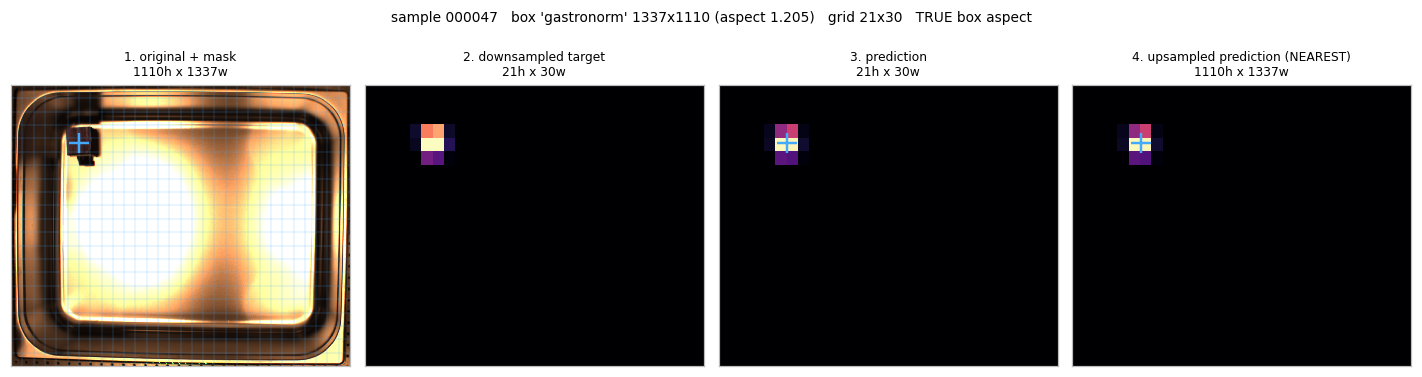

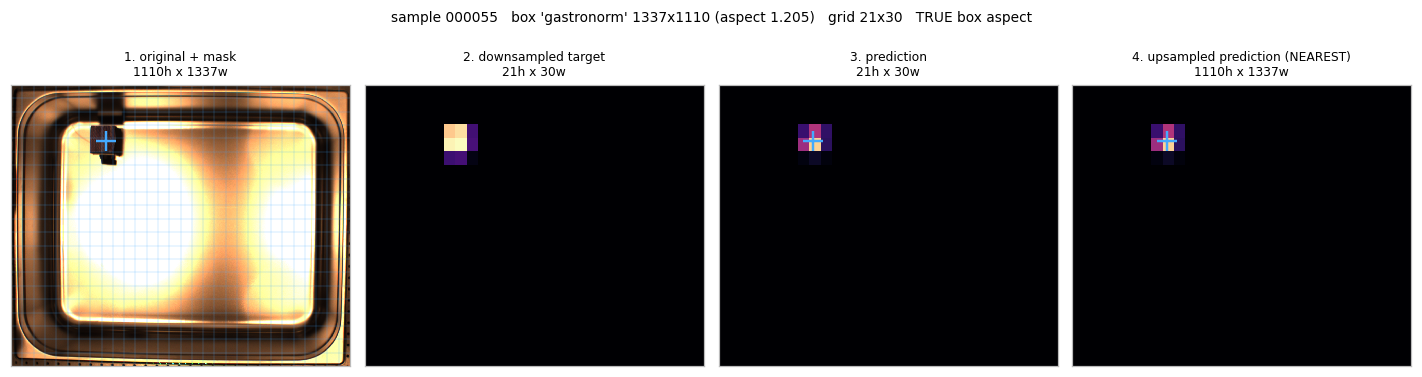

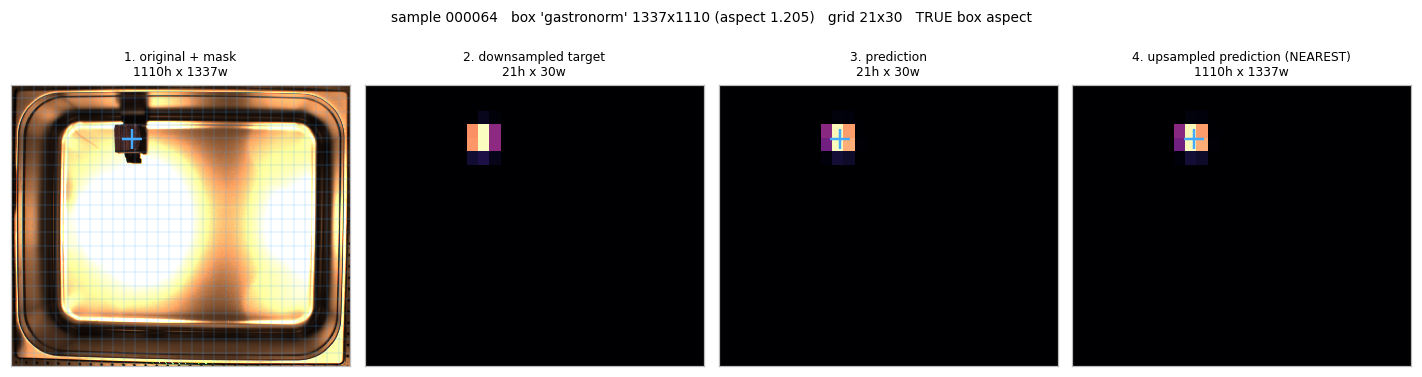

In [8]:
SHOW = 3   # first N samples of the batch

for i in range(SHOW):
    roundtrip_row(sids[i], preds[i], GRID_H, GRID_W, true_aspect=True)
plt.show()

### 2b. Square cells vs true aspect, in one frame - what wandb gets wrong today

`callbacks.py:_render` upscales the grid by one **isotropic** integer factor
(`scale = max(1, (target_w - sep) // (2 * w))`), so a `21x30` grid is always drawn at aspect
`30/21 = 1.43` no matter which box produced it. The real box is `1.205`. The overlay below is
the same prediction drawn both ways on top of the photo: the dashed outline is the square-cell
rendering, the solid one is the box's true frame. Today every wandb panel is the dashed shape.

The gap is ~19% horizontally for gastronorm. It is not a cosmetic issue once two boxes are in
one run, because each box gets a *different* wrong stretch and the panels stop being comparable
to each other.

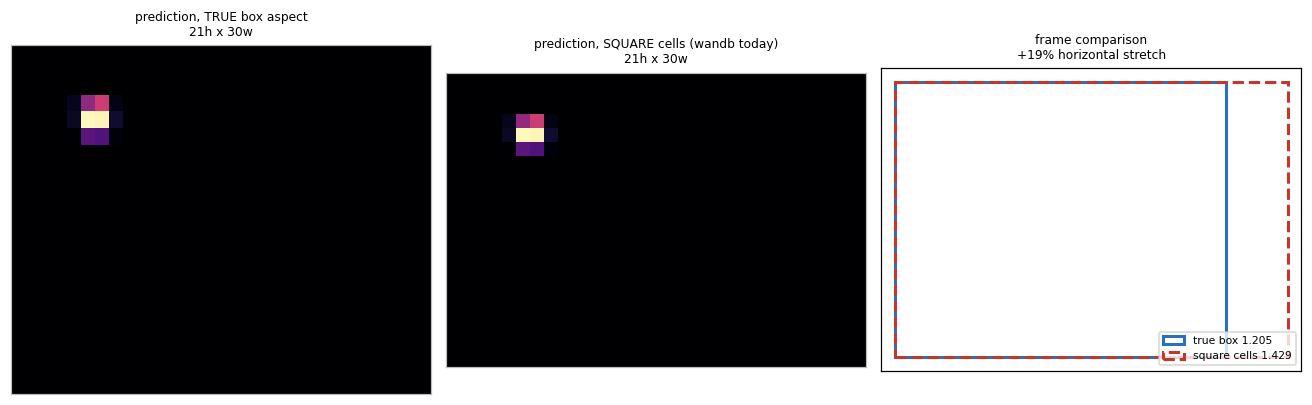

In [9]:
photo, _ = load_sample(sids[0]); bw, bh = photo.size
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

panel(axes[0], preds[0], "prediction, TRUE box aspect", bw, bh)
panel(axes[1], preds[0], "prediction, SQUARE cells (wandb today)")

# both renderings of the same grid, drawn to scale against each other
ax = axes[2]
true_w, true_h = bw / bh, 1.0                 # box frame, normalized to height 1
sq_w = (GRID_W / GRID_H) * true_h             # what square cells produce
ax.add_patch(Rectangle((0, 0), true_w, true_h, fill=False, ec="#2a70bb", lw=2, label=f"true box {bw/bh:.3f}"))
ax.add_patch(Rectangle((0, 0), sq_w, true_h, fill=False, ec="#c0392b", lw=2, ls="--",
                       label=f"square cells {GRID_W/GRID_H:.3f}"))
ax.set_xlim(-0.05, max(true_w, sq_w) + 0.05); ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=7, loc="lower right")
ax.set_title(f"frame comparison\n{100 * (sq_w / true_w - 1):+.0f}% horizontal stretch", fontsize=8)
fig.tight_layout(); plt.show()

### 2c. NEAREST vs BILINEAR on panel 4

NEAREST is the honest adjoint of `Image.BOX`: piecewise constant, at most `out_h*out_w` distinct
values, no gradient the lasers never measured. BILINEAR looks nicer and is fine as a *labelled*
cosmetic overlay, but it implies detail that is not there. Neither BICUBIC nor LANCZOS should be
used at all - they overshoot outside `[0,1]` and ring around blob edges.

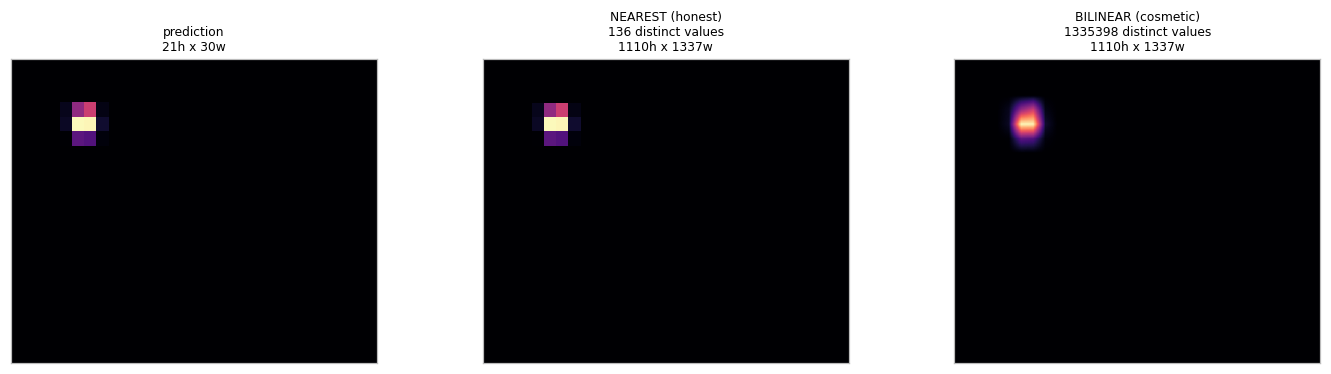

In [10]:
photo, _ = load_sample(sids[0]); bw, bh = photo.size
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
panel(axes[0], preds[0], "prediction", bw, bh)
for ax, sm in zip(axes[1:], (False, True)):
    up = upsample_mask(preds[0], bw, bh, smooth=sm)
    panel(ax, up, f"{'BILINEAR (cosmetic)' if sm else 'NEAREST (honest)'}\n"
                  f"{len(np.unique(up))} distinct values")
fig.tight_layout(); plt.show()

## 3. Does `32x32` wreck a box whose aspect is not 1?

Under the normalized frame a cell's real-space aspect is `box_aspect * (grid_h / grid_w)`. For
gastronorm (`1.204`): `21x30` gives `0.84` (cells 16% taller than wide) and `32x32` gives `1.20`
(cells 20% wider than tall). So **32x32 is not worse than today** for this box - both sit within
20% of square. The rows below are that claim on real pixels rather than on arithmetic.

No `32x32` model is trained yet, so panel 3 stays the `21x30` prediction and only the *target*
is recomputed at `32x32` (via `downsample_mask` directly - the `.npy` files for that size do not
exist on disk yet).

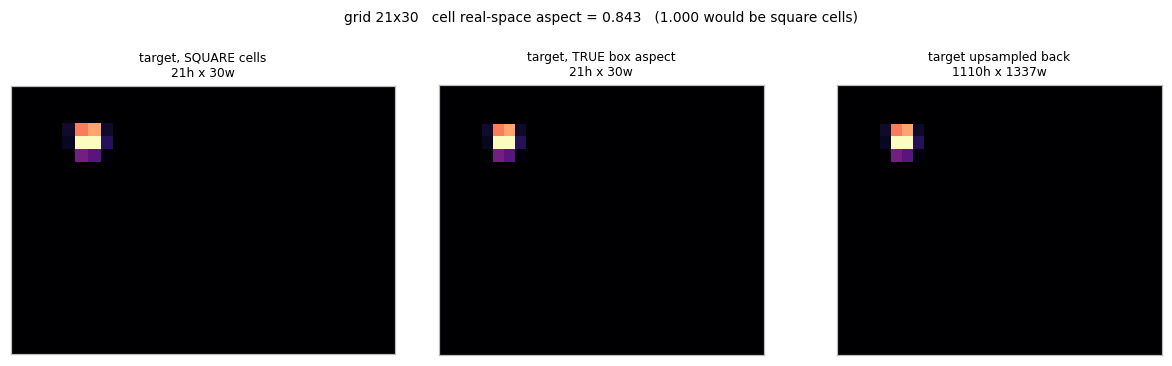

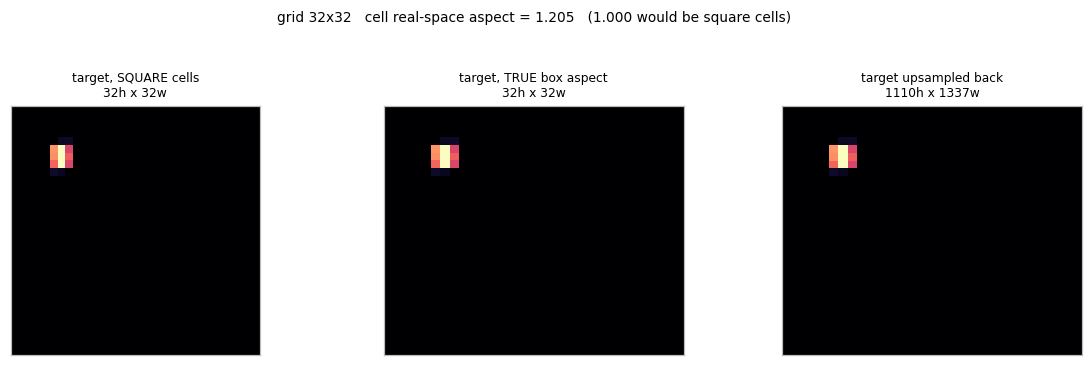

In [15]:
for h, w in [(21, 30), (32, 32)]:
    photo, smask = load_sample(sids[0]); bw, bh = photo.size
    gt = gt_grid(sids[0], h, w)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    panel(axes[0], gt, "target, SQUARE cells")
    panel(axes[1], gt, "target, TRUE box aspect", bw, bh)
    panel(axes[2], upsample_mask(gt, bw, bh), "target upsampled back")
    fig.suptitle(f"grid {h}x{w}   cell real-space aspect = "
                 f"{(bw/bh) * (h/w):.3f}   (1.000 would be square cells)", fontsize=9, y=1.02)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [16]:
# The aspect table from the plan, computed rather than asserted.
BOXES = {"gastronorm": (1337, 1110), "green-plastic": (1399, 1249), "2.5:1 tray (hypothetical)": (2500, 1000)}
print(f"{'grid':>10} | " + " | ".join(f"{n:>26}" for n in BOXES))
print("-" * 100)
for h, w in [(21, 30), (32, 32), (25, 30)]:
    row = " | ".join(f"{(bw/bh) * (h/w):>26.3f}" for bw, bh in BOXES.values())
    print(f"{h:>4}x{w:<5} | {row}")
print("\ncell real-space aspect = box_aspect * (grid_h/grid_w); 1.000 = square cells")

      grid |                 gastronorm |              green-plastic |  2.5:1 tray (hypothetical)
----------------------------------------------------------------------------------------------------
  21x30    |                      0.843 |                      0.784 |                      1.750
  32x32    |                      1.205 |                      1.120 |                      2.500
  25x30    |                      1.004 |                      0.933 |                      2.083

cell real-space aspect = box_aspect * (grid_h/grid_w); 1.000 = square cells


## 4. How honest is the roundtrip, exactly?

The claim to test is **not** losslessness - `Image.BOX` destroys information on the way down and
no inverse can recover it. The testable claim is that `NEAREST` upsampling is *consistent*:
re-binning it with `BOX` returns the grid you started from.

Block boundaries land at fractional pixels (`1337/32 = 41.78`, so cells get 41 or 42 px), which
is the only thing that can break exactness. The heatmap below shows where, and by how much.

/tmp/ipykernel_2597148/2904452336.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  back = np.array(Image.fromarray(up, mode="F").resize((grid_w, grid_h), resample=Image.BOX), np.float32)


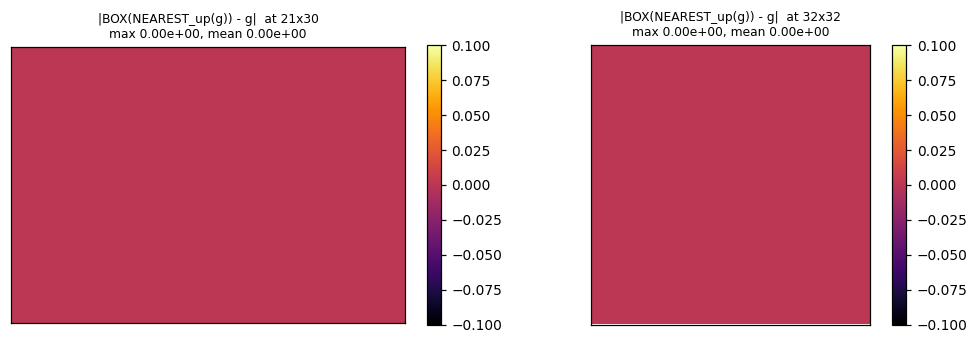

In [13]:
def roundtrip_err(smask, grid_h, grid_w):
    bw, bh = smask.size
    g  = downsample_mask(smask, grid_h, grid_w)
    up = upsample_mask(g, bw, bh)                      # NEAREST
    # re-bin in FLOAT (no uint8 quantization, which would add its own 1/255 error)
    back = np.array(Image.fromarray(up, mode="F").resize((grid_w, grid_h), resample=Image.BOX), np.float32)
    return g, np.abs(back - g)

_, smask = load_sample(sids[0])
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, (h, w) in zip(axes, [(21, 30), (32, 32)]):
    g, err = roundtrip_err(smask, h, w)
    im = ax.imshow(err, cmap="inferno", interpolation="nearest")
    ax.set_title(f"|BOX(NEAREST_up(g)) - g|  at {h}x{w}\nmax {err.max():.2e}, mean {err.mean():.2e}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); plt.show()

In [14]:
# Where does the fractional-boundary error actually bite? Random data, so nothing is
# accidentally smooth, across shapes that divide well and badly.
rng = np.random.default_rng(0)
print(f"{'full-res':>12} {'grid':>8} {'px/cell':>14} {'max err':>10}")
for (H, W) in [(1110, 1337), (1249, 1399), (101, 997), (313, 317)]:
    src = Image.fromarray((rng.random((H, W)) * 255).astype(np.uint8))
    for (h, w) in [(21, 30), (32, 32)]:
        _, err = roundtrip_err(src, h, w)
        print(f"{H}x{W:<7} {h}x{w:<5} {H/h:>6.1f}x{W/w:<6.1f} {err.max():>10.2e}")
print("\nExact where cells are many pixels across; the error only appears when a grid dimension")
print("is a large fraction of the source (101 rows -> 32 cells is ~3.2 px/cell). Both real boxes")
print("are ~35-60 px/cell, so the roundtrip is exact to float there.")

    full-res     grid        px/cell    max err
1110x1337    21x30      52.9x44.6     0.00e+00
1110x1337    32x32      34.7x41.8     0.00e+00
1249x1399    21x30      59.5x46.6     2.86e-04
1249x1399    32x32      39.0x43.7     0.00e+00
101x997     21x30       4.8x33.2     0.00e+00
101x997     32x32       3.2x31.2     2.44e-02
313x317     21x30      14.9x10.6     0.00e+00
313x317     32x32       9.8x9.9      0.00e+00

Exact where cells are many pixels across; the error only appears when a grid dimension
is a large fraction of the source (101 rows -> 32 cells is ~3.2 px/cell). Both real boxes
are ~35-60 px/cell, so the roundtrip is exact to float there.


/tmp/ipykernel_2597148/2904452336.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  back = np.array(Image.fromarray(up, mode="F").resize((grid_w, grid_h), resample=Image.BOX), np.float32)


## What this settles

Read the figures, then decide:

1. **Panel 1 vs panel 4** - if the blob lands in the same place at the same shape, the
   anisotropic `upsample_mask` is right and the rest of the plan can proceed on it.
2. **2a vs 2b** - the gap between them is exactly what `callbacks.py:_render` currently gets
   wrong, and what `viz`'s single global `scene_aspect()` will get wrong as soon as a second box
   is on screen.
3. **Section 3** - whether `32x32` is acceptable as the new default, or whether the
   letterbox-into-a-square-canvas variant is worth building now instead of later.